# Simulating DNA Sequencing Reads

A short simulation of a next-generation sequencing run and the quality-control checks that follow it.

Sequencing platforms do not read a genome end to end. They shear it into millions of short fragments, read each one base by base, and reassemble the results computationally. Every cycle of the machine reads position *n* across all fragments simultaneously, which means the aggregate base composition at each cycle is a diagnostic: in a well-prepared library of random fragments, each position should show roughly 25% of each base.

Systematic deviation from that flat line is one of the first signals that something has gone wrong upstream, whether in fragmentation, adapter ligation or amplification. Real QC tools report exactly this chart.

Confirming that an unbiased simulation produces unbiased output is a test of the code, not a useful result. The question worth answering is the inverse one: if a library genuinely is biased, how much sequencing does the check need before it notices? That is a power calculation, and it turns a chart someone eyeballs into a threshold with a stated error rate.

This notebook builds up to it in five parts:

1. Generating random fragments with their complementary strands
2. Measuring base composition across the run, and testing it against a uniform expectation
3. A gene expression matrix over time, and what a null result looks like
4. The three stages combined into a single pipeline
5. Introducing a deliberate GC bias and measuring how much data is needed to detect it

## 1. Generating fragments

Each fragment is a string over the alphabet `ATCG`, with each base drawn independently and uniformly. The antisense strand is built alongside it by complementing every base as it is generated: A pairs with T, C pairs with G. Building both strands in the same pass matters more than it looks. The alternative, generating the sense strand and reversing it afterwards, is a common source of error because the complementary strand runs antiparallel. Constructing them together keeps the correspondence explicit at every position.

In [1]:
import random

import pandas as pd

N_FRAGMENTS = 1000    # number of fragments to generate
FRAGMENT_LENGTH = 50  # bases per fragment
random.seed(42)       # fixed so the notebook reproduces exactly

COMPLEMENT = {"A": "T", "T": "A", "C": "G", "G": "C"}

def dna_frag(number, length):
    sense, antisense = [], []

    for _ in range(number):
        current_frag = ""
        current_anti_frag = ""

        for _ in range(length):
            base = random.choice("ATCG")
            current_frag += base
            current_anti_frag += COMPLEMENT[base]

        sense.append(current_frag)
        antisense.append(current_anti_frag)

    return sense, antisense

dna_sense, dna_antisense = dna_frag(N_FRAGMENTS, FRAGMENT_LENGTH)

dna = pd.DataFrame(
    [dna_sense, dna_antisense], index=["Sense", "Antisense"]
).T

dna.to_csv("dna.csv", index=False)

print(f"{len(dna):,} fragments of {FRAGMENT_LENGTH} bases")
dna.head(3)

1,000 fragments of 50 bases


,Sense,Antisense
0,AACTTTAAGAAATTATGTGCATGCCTTCAAGACCCAGAGACCTAAT...,TTGAAATTCTTTAATACACGTACGGAAGTTCTGGGTCTCTGGATTA...
1,GCGCTCCTCATTTGGCTCATACGCATCTGGGTCTTCGGCTTGAAAT...,CGCGAGGAGTAAACCGAGTATGCGTAGACCCAGAAGCCGAACTTTA...
2,GGCAACCACGTGACTACTTCTACGAACCTATAAGATTGTCGTTCGC...,CCGTTGGTGCACTGATGAAGATGCTTGGATATTCTAACAGCAAGCG...


The two columns should be complementary at every position. Worth checking rather than assuming, since a silent error here would propagate through everything that follows.

In [2]:
def is_complementary(sense, antisense):
    return all(COMPLEMENT[s] == a for s, a in zip(sense, antisense))

mismatches = sum(
    not is_complementary(s, a) for s, a in zip(dna["Sense"], dna["Antisense"])
)
print(f"Fragments with a complementarity error: {mismatches}")

Fragments with a complementarity error: 0


## 2. Base composition across the run

Sequencers read all fragments in parallel, one cycle per base position, so grouping fragments into blocks approximates reading the run in order. For each block we count the four bases and express them as proportions of the total.

The expected value for each is 0.25, since the generator draws uniformly. What is interesting is not the average but the spread: how far individual blocks stray from 0.25 is a function of how many bases each block contains, and that relationship is the basis for deciding how much data a QC check needs before its result means anything.

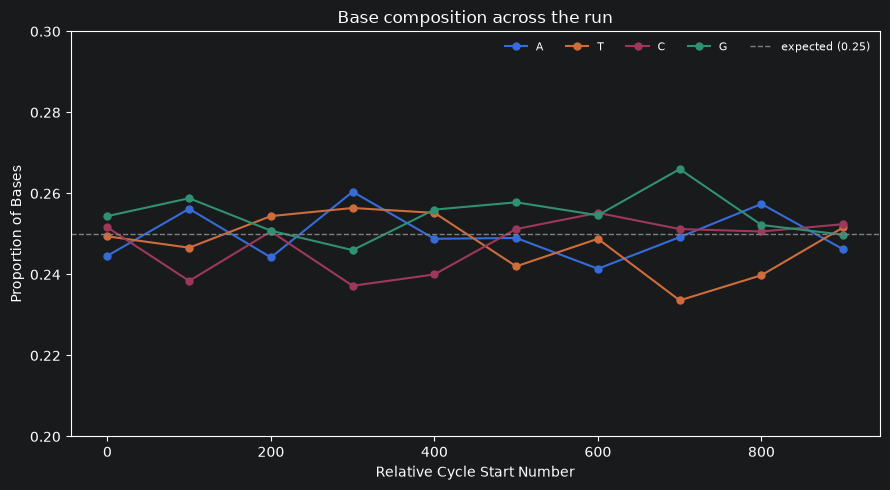

             A        T        C        G
count  10.0000  10.0000  10.0000  10.0000
mean    0.2497   0.2478   0.2478   0.2546
std     0.0063   0.0074   0.0066   0.0055
min     0.2414   0.2336   0.2372   0.2460
25%     0.2450   0.2432   0.2426   0.2512
50%     0.2489   0.2491   0.2509   0.2545
75%     0.2544   0.2537   0.2515   0.2573
max     0.2604   0.2564   0.2552   0.2660


In [3]:
import matplotlib.pyplot as plt

data = pd.read_csv("dna.csv")

# Count each base in every sense-strand fragment
base_list = []
for sequence in data["Sense"]:
    base_count = {}
    for base in sequence:
        base_count[base] = base_count.get(base, 0) + 1
    base_list.append(base_count)

counted = pd.DataFrame(base_list).fillna(0).astype(float)
counted["Total"] = counted[["A", "T", "C", "G"]].sum(axis=1)

# Split into ten blocks to approximate reading the run in order
block_size = round(len(counted) / 10)
rows = []

for start in range(0, len(counted), block_size):
    block = counted[start:start + block_size].sum(axis=0)
    row = {"Start Sequence Number": start}
    for base in "ATCG":
        row[base] = block[base] / block["Total"]
    rows.append(row)

graph_points = pd.DataFrame(rows)

ax = graph_points.plot(
    x="Start Sequence Number", y=["A", "T", "C", "G"],
    marker=".", markersize=10, figsize=(9, 5),
)
ax.axhline(0.25, color="grey", linestyle="--", linewidth=1, label="expected (0.25)")
ax.set_xlabel("Relative Cycle Start Number")
ax.set_ylabel("Proportion of Bases")
ax.set_title("Base composition across the run")
ax.set_ylim(0.2, 0.3)
ax.legend(frameon=False, ncol=5, fontsize=8)
plt.tight_layout()
plt.show()

print(graph_points[["A", "T", "C", "G"]].describe().round(4))

The four series scatter around 0.25 with no trend, which is the correct result: the generator is unbiased by construction, so any structure in this chart would indicate a bug rather than a biological finding.

The size of that scatter is the useful quantity. Each block here contains 5,000 bases, and the standard error on a proportion is `sqrt(p(1-p)/n)`, giving roughly 0.006 at p = 0.25. Deviations of one or two percentage points are therefore expected noise, not signal, and a QC threshold set tighter than that would raise false alarms on every run.

**A test worth adding.** Whether these counts differ from a uniform expectation is a chi-square goodness-of-fit question, and answering it turns an eyeballed chart into a decision with a stated error rate.

In [4]:
from scipy.stats import chisquare

observed = counted[["A", "T", "C", "G"]].sum().values
expected = [observed.sum() / 4] * 4

stat, p = chisquare(f_obs=observed, f_exp=expected)

print(f"Observed counts: {dict(zip('ATCG', observed.astype(int)))}")
print(f"Expected (uniform): {int(expected[0]):,} each")
print(f"chi-square = {stat:.2f}, p = {p:.3f}")
print(
    "\nNo evidence against uniformity." if p > 0.05
    else "\nDeviation from uniformity is significant at the 5% level."
)

Observed counts: {'A': np.int64(12487), 'T': np.int64(12389), 'C': np.int64(12392), 'G': np.int64(12732)}
Expected (uniform): 12,500 each
chi-square = 6.24, p = 0.101

No evidence against uniformity.


A high p-value here is the expected outcome and does not prove the generator is unbiased. It says the data are consistent with uniformity, which is a weaker claim: the test has limited power to detect small deviations at this sample size. Establishing what size of bias this design *could* detect would require a power calculation, and that is the question a real QC threshold has to answer.

## 3. Gene expression over time

A second, unrelated simulation: a matrix of 10,000 genes scored at six time points, with scores drawn uniformly from 0 to 1. Averaging each column gives the mean score at each point.

This is deliberately a null. The values are independent draws with no time structure, so the six means differ only by sampling noise, and the resulting line should be flat to within about 0.003. Plotting it is worth doing precisely because of what it teaches: a chart with visible peaks and troughs will still be produced, and reading a trend into it would be reading noise. Knowing what pure noise looks like at a given sample size is what makes a real signal recognisable.

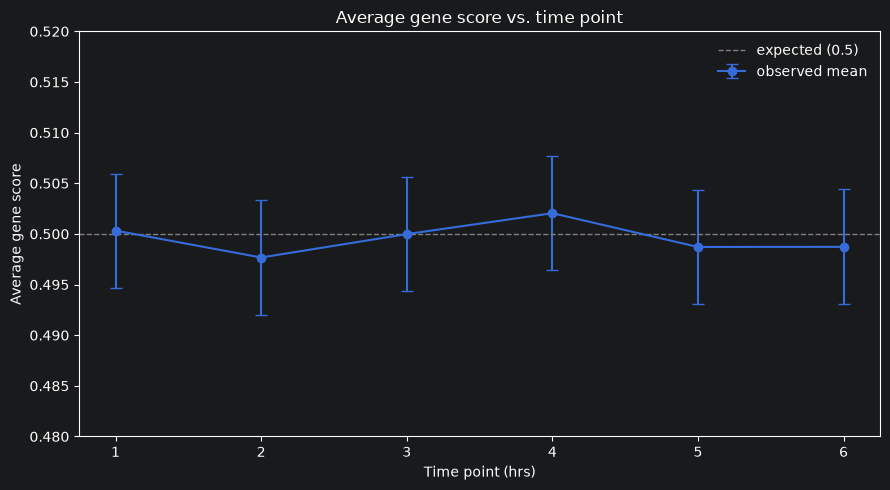

Range across time points: 0.0044
95% CI half-width: 0.0057


In [5]:
import numpy as np

np.random.seed(42)

gene_array = np.random.rand(10000, 6)
time_point = np.arange(1, 7)

processed_array = np.mean(gene_array, axis=0)
standard_error = gene_array.std(axis=0, ddof=1) / np.sqrt(gene_array.shape[0])

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(time_point, processed_array, yerr=1.96 * standard_error,
            marker="o", capsize=4, label="observed mean")
ax.axhline(0.5, color="grey", linestyle="--", linewidth=1, label="expected (0.5)")
ax.set_title("Average gene score vs. time point")
ax.set_xlabel("Time point (hrs)")
ax.set_ylabel("Average gene score")
ax.set_ylim(0.48, 0.52)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print(f"Range across time points: {np.ptp(processed_array):.4f}")
print(f"95% CI half-width: {1.96 * standard_error.mean():.4f}")

Note the y-axis. Restricted to a narrow band, the line looks like it has structure; on a 0 to 1 scale it would be visually flat. Axis choice alone can make noise look like a finding, which is why the confidence intervals matter more than the line joining the points. Every interval overlaps every other, so no pair of time points is distinguishable.

## 4. The pipeline end to end

The three stages combined: generate fragments, count bases, report composition, without writing to disk in between. This is the form the code would take if it were run routinely rather than explored interactively.

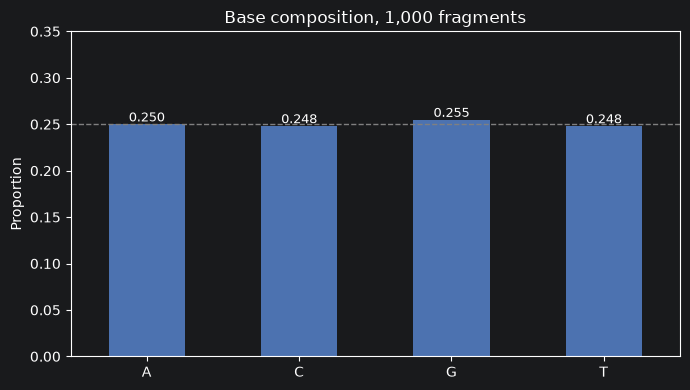

In [6]:
def simulate_run(n_fragments, fragment_length, seed=None):
    if seed is not None:
        random.seed(seed)

    sense, _ = dna_frag(n_fragments, fragment_length)

    counts = {}
    for sequence in sense:
        for base in sequence:
            counts[base] = counts.get(base, 0) + 1

    proportions = pd.Series(counts).sort_index()
    return sense, proportions / proportions.sum()

fragments, proportions = simulate_run(N_FRAGMENTS, FRAGMENT_LENGTH, seed=42)

ax = proportions.plot.bar(figsize=(7, 4), color="#4C72B0", rot=0)
ax.axhline(0.25, color="grey", linestyle="--", linewidth=1)
ax.set_title(f"Base composition, {len(fragments):,} fragments")
ax.set_ylabel("Proportion")
ax.set_ylim(0, 0.35)
for i, v in enumerate(proportions):
    ax.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

## What this does and does not show

The simulation reproduces the structure of a sequencing QC check and confirms that an unbiased generator produces unbiased output. That is a test of the code, not a finding about biology.

The more useful output is the calibration. With 50,000 bases the standard error on a base proportion is around 0.002, so deviations below roughly half a percentage point are indistinguishable from chance. That number, rather than the chart, is what a QC threshold should be set from.

**The obvious extension.** Everything here is drawn from a known uniform distribution, so there is nothing to detect. Introducing a deliberate bias, for example generating fragments at 30% GC instead of 25%, would turn this into a detection problem: at what read depth does the chi-square test reliably reject, and what is the smallest bias detectable at a given number of reads? That is a power calculation, and it is the question that decides how much sequencing a QC check actually requires.

## 5. How much data does the check need?

Everything above draws from a uniform distribution, so there is no bias present and nothing to detect. The chi-square test returning a high p-value confirms the code works; it says nothing about whether the check would catch a real problem.

The question that matters operationally is the inverse one. Given a QC check that flags deviation from uniform base composition, how much sequencing does it need before it reliably detects a library that genuinely is biased? Set the threshold on too little data and real problems pass; demand too much and the check is expensive to run.

**Framing the bias.** GC content is the conventional measure: the proportion of bases that are G or C. Uniform ATCG gives 50% GC, since G and C together are half the alphabet. A biased library shifts that, so generating fragments at 52% GC means drawing G and C with probability 0.26 each and A and T with 0.24.

**Method.** For each combination of read depth and true GC content, simulate many independent runs, test each against a uniform expectation, and record the proportion rejected at the 5% level. That proportion is the statistical power of the check: the probability it catches a bias of that size at that depth.

Two things to look for. At 50% GC there is no bias, so the rejection rate should sit at 0.05 regardless of depth, since that is the false positive rate the test was specified with. Everywhere else the rate should climb with depth, and the steepness of that climb is what answers the question.

Counts are drawn directly from a multinomial rather than by building strings base by base. Only the four totals affect the test, so simulating them directly gives an identical distribution for a fraction of the runtime, which is what makes thousands of replicates practical.

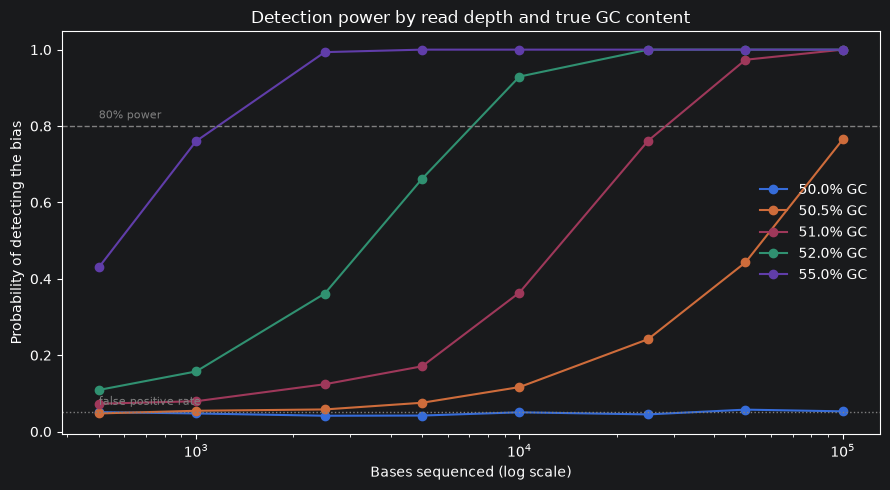

                 50.0%  50.5%  51.0%  52.0%  55.0%
Bases sequenced                                   
500              0.051  0.048  0.073  0.109  0.430
1000             0.048  0.054  0.080  0.158  0.760
2500             0.042  0.058  0.124  0.362  0.994
5000             0.042  0.076  0.171  0.662  1.000
10000            0.050  0.116  0.364  0.930  1.000
25000            0.045  0.242  0.762  1.000  1.000
50000            0.058  0.443  0.974  1.000  1.000
100000           0.053  0.765  1.000  1.000  1.000

Depth required for 80% power:
50.0% GC: not reached at 100,000
50.5% GC: not reached at 100,000
51.0% GC: 50,000 bases
52.0% GC: 10,000 bases
55.0% GC: 2,500 bases


In [7]:
from scipy.stats import chisquare

rng = np.random.default_rng(42)

DEPTHS = [500, 1_000, 2_500, 5_000, 10_000, 25_000, 50_000, 100_000]
GC_LEVELS = [0.50, 0.505, 0.51, 0.52, 0.55]
N_TRIALS = 2_000
ALPHA = 0.05

def base_probabilities(gc_content):
    at = (1 - gc_content) / 2
    gc = gc_content / 2
    return [at, at, gc, gc]


def detection_rate(n_bases, gc_content, n_trials=N_TRIALS, alpha=ALPHA):
    draws = rng.multinomial(n_bases, base_probabilities(gc_content), size=n_trials)
    _, p_values = chisquare(f_obs=draws, f_exp=[n_bases / 4] * 4, axis=1)
    return (p_values < alpha).mean()

power = pd.DataFrame(
    {f"{gc:.1%}": [detection_rate(n, gc) for n in DEPTHS] for gc in GC_LEVELS},
    index=DEPTHS,
)
power.index.name = "Bases sequenced"

fig, ax = plt.subplots(figsize=(9, 5))
for col in power.columns:
    ax.plot(power.index, power[col], marker="o", label=f"{col} GC")

ax.axhline(0.8, color="grey", linestyle="--", linewidth=1)
ax.axhline(ALPHA, color="grey", linestyle=":", linewidth=1)
ax.text(power.index[0], 0.82, "80% power", fontsize=8, color="grey")
ax.text(power.index[0], 0.07, "false positive rate", fontsize=8, color="grey")
ax.set_xscale("log")
ax.set_xlabel("Bases sequenced (log scale)")
ax.set_ylabel("Probability of detecting the bias")
ax.set_title("Detection power by read depth and true GC content")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print(power.round(3).to_string())
print("\nDepth required for 80% power:")
for col in power.columns:
    reached = power.index[power[col] >= 0.8]
    print(f"{col} GC: {f'{reached[0]:,} bases' if len(reached) else 'not reached at 100,000'}")

The 50% line sits flat at 0.05 across every depth, which is the check working correctly: with no bias present, it raises a false alarm exactly as often as its significance level says it should, and no amount of extra data changes that.

The other curves give the operational answer:

| True GC | Bases for 80% power |
|---|---|
| 51% | 50,000 |
| 52% | 10,000 |
| 55% | 2,500 |

A 5-point deviation is caught almost immediately. A 1-point deviation needs twenty times the data. A half-point deviation is not reliably detected even at 100,000 bases, which is the more useful finding: it establishes a floor on what this check can see, and any claim that a library is unbiased is only meaningful relative to that floor.

The shape of the relationship is why. Detecting a difference of size *d* requires roughly 1/*d*² observations, so halving the bias you want to catch quadruples the sequencing required. That is what makes small systematic biases expensive to rule out and easy to miss.

**What this changes about the earlier result.** Section 2 reported no evidence against uniformity at 50,000 bases. That is now a quantified statement rather than a reassuring one: at that depth the check would have detected a 1-point GC bias about 44% of the time and a 2-point bias essentially always. The absence of a signal rules out a large bias and says very little about a small one.